# **Classificador de Notícias Financeiras (Reuters)**

**Aluno:** Marllus Coutinho Nascimento Júnior

**Matricula:** 202505642

---

🧠 **Contexto de aplicação:**

Empresas e organizações financeiras recebem diariamente um grande volume de notícias. A classificação automática desses conteúdos pode auxiliar na organização e direcionamento das informações, especialmente para análises de mercado e tomada de decisões.

**A proposta ao problema:** construir um modelo de Inteligência Artificial capaz de **classificar automaticamente notícias financeiras em diferentes categorias**, utilizando o conjunto de dados **Reuters**.

**Pipeline do Projeto de IA:**

Dados → Pré-processamento → Modelo → Treinamento → Validação → Teste → Inferência

**Fonte de dados (notícias)**

O Keras possui o conjunto de dados **Reuters**, composto por notícias previamente classificadas em categorias.

Cada notícia é representada por uma sequência de números, onde cada número corresponde a uma palavra do vocabulário. O objetivo será utilizar essas sequências para treinar um modelo capaz de identificar a categoria de uma nova notícia.

Um desafio do conjunto de dados é o **desbalanceamento entre as categorias**, que será analisado durante o projeto.

## **1. Bibliotecas**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.sequence import pad_sequences

## **2. Carregando os dados de Treino e Teste**

In [ ]:
# Número de palavras mais frequentes do vocabulário que serão consideradas
NUM_PALAVRAS = 10000

# Carrega o dataset Reuters, que já está disponível no Keras
(x_treino, y_treino), (x_teste, y_teste) = datasets.reuters.load_data(
    num_words=NUM_PALAVRAS
)

print("Treino:", x_treino.shape)
print("Teste :", x_teste.shape)

Treino: (8982,)
Teste : (2246,)


In [ ]:
# Obtém os nomes das categorias do dataset Reuters
nomes_categorias = datasets.reuters.get_label_names()

print("Quantidade de categorias:", len(nomes_categorias))
print(nomes_categorias)

Quantidade de categorias: 46
('cocoa', 'grain', 'veg-oil', 'earn', 'acq', 'wheat', 'copper', 'housing', 'money-supply', 'coffee', 'sugar', 'trade', 'reserves', 'ship', 'cotton', 'carcass', 'crude', 'nat-gas', 'cpi', 'money-fx', 'interest', 'gnp', 'meal-feed', 'alum', 'oilseed', 'gold', 'tin', 'strategic-metal', 'livestock', 'retail', 'ipi', 'iron-steel', 'rubber', 'heat', 'jobs', 'lei', 'bop', 'zinc', 'orange', 'pet-chem', 'dlr', 'gas', 'silver', 'wpi', 'hog', 'lead')


## **3. Explorando os dados**

In [ ]:
# Visualiza uma notícia do conjunto de treino
print("Exemplo de notícia:")
print(x_treino[0])

print("\nCategoria da notícia:")
print(y_treino[0])

print("\nQuantidade de palavras na notícia:")
print(len(x_treino[0]))

Exemplo de notícia:
[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]

Categoria da notícia:
3

Quantidade de palavras na notícia:
87


In [ ]:
# Quantidade de notícias em cada categoria
categorias, quantidades = np.unique(
    y_treino,
    return_counts=True
)

print("Quantidade de categorias:", len(categorias))

for categoria, quantidade in zip(categorias, quantidades):
    print(
        f"{categoria} - {nomes_categorias[categoria]}: "
        f"{quantidade} notícias"
    )

Quantidade de categorias: 46
0 - cocoa: 55 notícias
1 - grain: 432 notícias
2 - veg-oil: 74 notícias
3 - earn: 3159 notícias
4 - acq: 1949 notícias
5 - wheat: 17 notícias
6 - copper: 48 notícias
7 - housing: 16 notícias
8 - money-supply: 139 notícias
9 - coffee: 101 notícias
10 - sugar: 124 notícias
11 - trade: 390 notícias
12 - reserves: 49 notícias
13 - ship: 172 notícias
14 - cotton: 26 notícias
15 - carcass: 20 notícias
16 - crude: 444 notícias
17 - nat-gas: 39 notícias
18 - cpi: 66 notícias
19 - money-fx: 549 notícias
20 - interest: 269 notícias
21 - gnp: 100 notícias
22 - meal-feed: 15 notícias
23 - alum: 41 notícias
24 - oilseed: 62 notícias
25 - gold: 92 notícias
26 - tin: 24 notícias
27 - strategic-metal: 15 notícias
28 - livestock: 48 notícias
29 - retail: 19 notícias
30 - ipi: 45 notícias
31 - iron-steel: 39 notícias
32 - rubber: 32 notícias
33 - heat: 11 notícias
34 - jobs: 50 notícias
35 - lei: 10 notícias
36 - bop: 49 notícias
37 - zinc: 19 notícias
38 - orange: 19 notíci

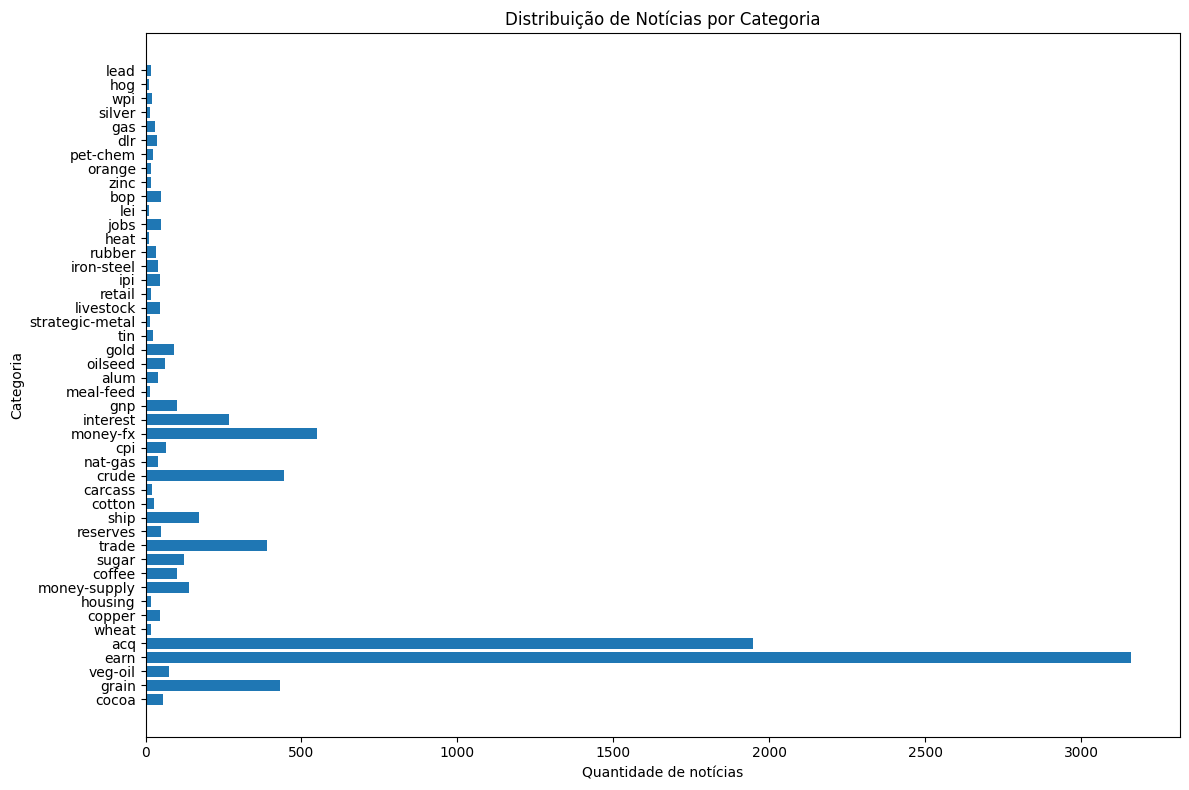

In [ ]:
plt.figure(figsize=(12, 8))

plt.barh(
    [nomes_categorias[c] for c in categorias],
    quantidades
)

plt.xlabel("Quantidade de notícias")
plt.ylabel("Categoria")
plt.title("Distribuição de Notícias por Categoria")

plt.tight_layout()
plt.show()

## **4. Desbalanceamento das Classes**

Ao analisar a distribuição dos dados, é possível observar que algumas categorias possuem muito mais notícias do que outras.

Esse desbalanceamento pode influenciar o treinamento do modelo, fazendo com que ele tenha maior facilidade para aprender as categorias mais frequentes e maior dificuldade para identificar categorias com poucos exemplos.

Para reduzir esse efeito, serão utilizados **pesos de classe (class weights)** durante o treinamento. Dessa forma, erros cometidos em categorias menos frequentes terão maior importância para o modelo.

In [ ]:
# Calcula pesos para compensar o desbalanceamento das classes
total = len(y_treino)
num_categorias = len(categorias)

pesos_classes = {
    categoria: total / (num_categorias * quantidade)
    for categoria, quantidade in zip(categorias, quantidades)
}

# Visualiza os pesos calculados
for categoria, peso in pesos_classes.items():
    print(f"Categoria {categoria}: peso {peso:.2f}")

Categoria 0: peso 3.55
Categoria 1: peso 0.45
Categoria 2: peso 2.64
Categoria 3: peso 0.06
Categoria 4: peso 0.10
Categoria 5: peso 11.49
Categoria 6: peso 4.07
Categoria 7: peso 12.20
Categoria 8: peso 1.40
Categoria 9: peso 1.93
Categoria 10: peso 1.57
Categoria 11: peso 0.50
Categoria 12: peso 3.98
Categoria 13: peso 1.14
Categoria 14: peso 7.51
Categoria 15: peso 9.76
Categoria 16: peso 0.44
Categoria 17: peso 5.01
Categoria 18: peso 2.96
Categoria 19: peso 0.36
Categoria 20: peso 0.73
Categoria 21: peso 1.95
Categoria 22: peso 13.02
Categoria 23: peso 4.76
Categoria 24: peso 3.15
Categoria 25: peso 2.12
Categoria 26: peso 8.14
Categoria 27: peso 13.02
Categoria 28: peso 4.07
Categoria 29: peso 10.28
Categoria 30: peso 4.34
Categoria 31: peso 5.01
Categoria 32: peso 6.10
Categoria 33: peso 17.75
Categoria 34: peso 3.91
Categoria 35: peso 19.53
Categoria 36: peso 3.98
Categoria 37: peso 10.28
Categoria 38: peso 10.28
Categoria 39: peso 8.14
Categoria 40: peso 5.42
Categoria 41: pes

In [ ]:
class_weight=pesos_classes

## **5. Pré-processamento**

As notícias possuem tamanhos diferentes, pois cada texto contém uma quantidade diferente de palavras.

Para que os dados possam ser utilizados pelo modelo, todas as sequências precisam possuir o mesmo tamanho. Para isso, será utilizado o **padding**, que completa ou reduz as sequências para um comprimento definido.

Antes disso, vamos analisar o tamanho das notícias para escolher um valor adequado.

In [ ]:
# Calcula o tamanho de cada notícia
tamanhos = [len(noticia) for noticia in x_treino]

print("Menor notícia:", np.min(tamanhos), "palavras")
print("Maior notícia:", np.max(tamanhos), "palavras")
print("Tamanho médio:", int(np.mean(tamanhos)), "palavras")
print("Mediana:", int(np.median(tamanhos)), "palavras")

Menor notícia: 13 palavras
Maior notícia: 2376 palavras
Tamanho médio: 145 palavras
Mediana: 95 palavras


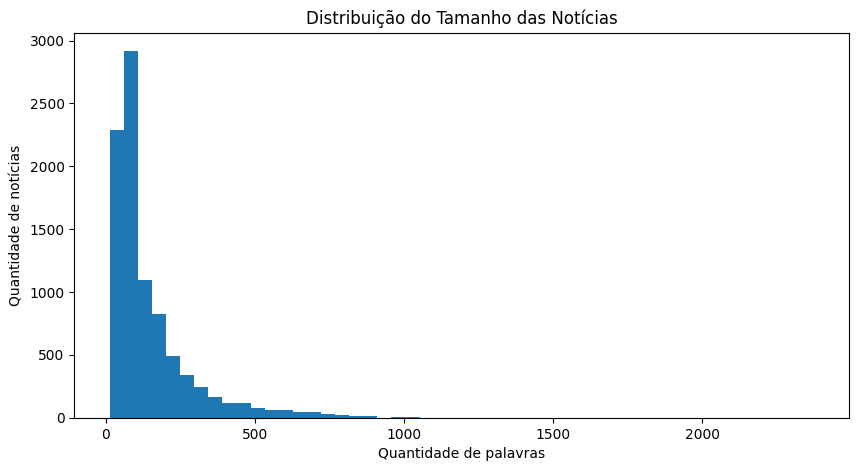

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(tamanhos, bins=50)

plt.xlabel("Quantidade de palavras")
plt.ylabel("Quantidade de notícias")
plt.title("Distribuição do Tamanho das Notícias")

plt.show()

### **5.1 Definindo o tamanho das sequências**

A maioria das notícias possui poucas centenas de palavras, embora existam alguns textos muito maiores.

Para definir um tamanho adequado para as sequências, vamos verificar qual comprimento é suficiente para representar a maior parte das notícias, evitando aumentar desnecessariamente o tamanho dos dados.

In [ ]:
# Verifica o tamanho das notícias em diferentes percentis
print("75% das notícias possuem até:", int(np.percentile(tamanhos, 75)), "palavras")
print("90% das notícias possuem até:", int(np.percentile(tamanhos, 90)), "palavras")
print("95% das notícias possuem até:", int(np.percentile(tamanhos, 95)), "palavras")

75% das notícias possuem até: 179 palavras
90% das notícias possuem até: 313 palavras
95% das notícias possuem até: 459 palavras


### **Padronização das sequências**

Como as notícias possuem tamanhos diferentes, será definido um tamanho máximo de **300 palavras** por notícia.

As notícias menores serão completadas com zeros, enquanto as notícias maiores serão limitadas às 300 primeiras posições.

Essa padronização permite que todas as entradas tenham o mesmo tamanho e possam ser utilizadas no treinamento da rede neural.

In [ ]:
# Define o tamanho máximo das sequências
MAX_LEN = 300

# Padroniza as sequências de treino e teste
x_treino_pad = pad_sequences(
    x_treino,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

x_teste_pad = pad_sequences(
    x_teste,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Formato do treino:", x_treino_pad.shape)
print("Formato do teste :", x_teste_pad.shape)

Formato do treino: (8982, 300)
Formato do teste : (2246, 300)


## **6. Construção do Modelo**

Com os dados preparados, podemos construir a rede neural responsável pela classificação das notícias.

O modelo utilizará uma camada **Embedding**, que transforma os números que representam as palavras em vetores numéricos aprendidos durante o treinamento.

Em seguida, essas informações serão resumidas e processadas por camadas densas. A camada de saída possuirá **46 neurônios**, correspondentes às 46 categorias existentes no conjunto de dados.

In [ ]:
modelo = models.Sequential([

    # Define o formato de entrada das notícias
    layers.Input(shape=(MAX_LEN,)),

    # Representação das palavras
    layers.Embedding(
        input_dim=NUM_PALAVRAS,
        output_dim=64
    ),

    # Resume as informações da sequência
    layers.GlobalAveragePooling1D(),

    # Camada intermediária
    layers.Dense(64, activation="relu"),

    # Ajuda a reduzir overfitting
    layers.Dropout(0.3),

    # 46 categorias possíveis
    layers.Dense(46, activation="softmax")
])

In [ ]:
modelo.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 300, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 647,150 (2.47 MB)

 Trainable params: 647,150 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

### **Compilação do Modelo**

Antes do treinamento, é necessário configurar como o modelo irá aprender.

Como o problema possui **46 categorias**, utilizaremos a função de perda `sparse_categorical_crossentropy`, adequada para problemas de classificação com múltiplas classes quando as categorias são representadas por números inteiros.

Também utilizaremos o otimizador **Adam** e a **acurácia** como métrica inicial de acompanhamento.

In [ ]:
modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Modelo compilado com sucesso!")

Modelo compilado com sucesso!


## **7. Treinamento e Validação**

Com o modelo construído e compilado, podemos iniciar o treinamento.

Durante o treinamento, parte dos dados será utilizada para **validação**, permitindo acompanhar o desempenho do modelo em dados que não estão sendo utilizados diretamente para ajustar seus parâmetros.

Também serão utilizados os **pesos das classes** calculados anteriormente, com o objetivo de reduzir o impacto do desbalanceamento existente entre as categorias.

In [ ]:
historico = modelo.fit(
    x_treino_pad,
    y_treino,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=pesos_classes
)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.1467 - loss: 3.8258 - val_accuracy: 0.0996 - val_loss: 3.7807
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.2617 - loss: 3.7929 - val_accuracy: 0.3472 - val_loss: 3.5699
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.2834 - loss: 3.7263 - val_accuracy: 0.3567 - val_loss: 3.3685
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3198 - loss: 3.5989 - val_accuracy: 0.1658 - val_loss: 3.6828
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3532 - loss: 3.4096 - val_accuracy: 0.3372 - val_loss: 3.1280
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.3747 - loss: 3.1399 - val_accuracy: 0.4335 - val_loss: 2.8641
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.3826 - loss: 2.9376 - val_accuracy: 0.4858 - val_loss: 2.7042
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4398 - loss: 2.6743 - val_accu

### **Análise do Treinamento**

Após o treinamento, podemos comparar o desempenho do modelo nos dados de treino e validação.

Essa análise permite observar se o modelo continua melhorando ao longo das épocas e identificar possíveis diferenças entre o aprendizado no conjunto de treino e no conjunto de validação.

In [ ]:
# Recupera os resultados do treinamento
acc = historico.history["accuracy"]
val_acc = historico.history["val_accuracy"]

loss = historico.history["loss"]
val_loss = historico.history["val_loss"]

epocas = range(1, len(acc) + 1)

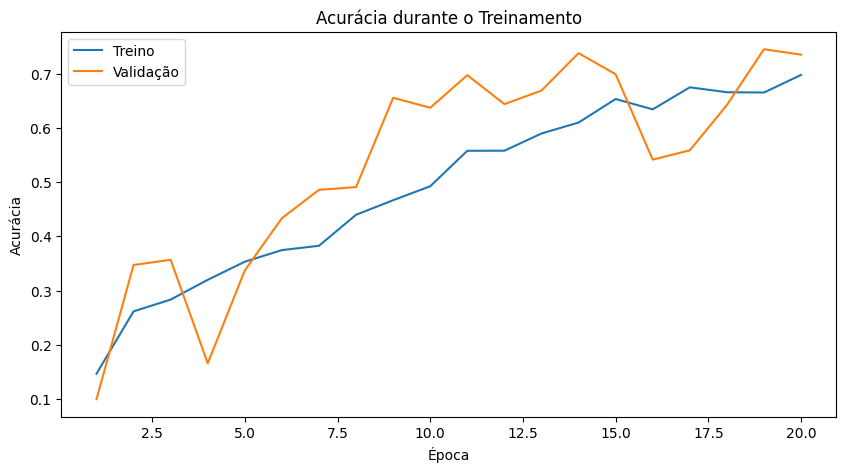

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(epocas, acc, label="Treino")
plt.plot(epocas, val_acc, label="Validação")

plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Acurácia durante o Treinamento")
plt.legend()

plt.show()

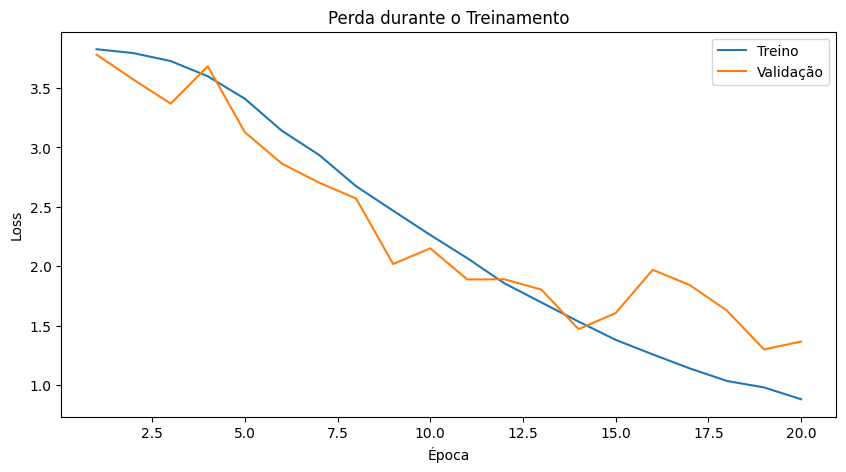

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(epocas, loss, label="Treino")
plt.plot(epocas, val_loss, label="Validação")

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Perda durante o Treinamento")
plt.legend()

plt.show()

### **Análise dos resultados do treinamento**

Os gráficos mostram que o modelo apresentou evolução durante o treinamento, com aumento da acurácia e redução da perda.

Nos dados de validação também houve melhora, embora com algumas oscilações ao longo das épocas. Nas últimas épocas, enquanto a perda de treinamento continuou diminuindo, a perda de validação apresentou aumento.

Esse comportamento indica um possível início de **overfitting**, ou seja, o modelo começa a se ajustar melhor aos dados de treinamento sem apresentar a mesma melhora nos dados de validação.

## **8. Avaliação do Modelo**

Após o treinamento e a validação, o modelo será avaliado utilizando o conjunto de teste.

Esses dados não foram utilizados durante o treinamento e permitem verificar a capacidade do modelo de classificar novas notícias.

In [ ]:
loss_teste, acuracia_teste = modelo.evaluate(
    x_teste_pad,
    y_teste,
    verbose=0
)

print(f"Loss no teste: {loss_teste:.4f}")
print(f"Acurácia no teste: {acuracia_teste:.4f}")
print(f"Acurácia no teste: {acuracia_teste * 100:.2f}%")

Loss no teste: 1.3379
Acurácia no teste: 0.7320
Acurácia no teste: 73.20%


### **Avaliação considerando o desbalanceamento**

Como o conjunto Reuters apresenta um forte desbalanceamento entre suas 46 categorias, a acurácia isoladamente pode não representar completamente o desempenho do modelo.

Por isso, também serão analisadas as métricas **Precision, Recall e F1-score**, permitindo avaliar melhor o comportamento do modelo entre as diferentes categorias.

In [ ]:
from sklearn.metrics import classification_report, f1_score

# Realiza as previsões no conjunto de teste
probabilidades = modelo.predict(x_teste_pad, verbose=0)

# Seleciona a categoria com maior probabilidade
y_pred = np.argmax(probabilidades, axis=1)

# Exibe as métricas por categoria
print(classification_report(
    y_teste,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.89      0.67      0.76        12
           1       0.73      0.67      0.70       105
           2       0.69      0.45      0.55        20
           3       0.93      0.83      0.88       813
           4       0.79      0.80      0.79       474
           5       0.50      0.20      0.29         5
           6       0.90      0.64      0.75        14
           7       0.50      1.00      0.67         3
           8       0.24      0.71      0.36        38
           9       0.80      0.80      0.80        25
          10       0.88      0.70      0.78        30
          11       0.73      0.66      0.70        83
          12       0.36      0.62      0.46        13
          13       0.53      0.68      0.60        37
          14       0.50      0.50      0.50         2
          15       0.22      0.22      0.22         9
          16       0.80      0.72      0.76        99
          17       0.50    

In [ ]:
f1_macro = f1_score(
    y_teste,
    y_pred,
    average="macro",
    zero_division=0
)

f1_weighted = f1_score(
    y_teste,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"F1-score Macro: {f1_macro:.4f}")
print(f"F1-score Weighted: {f1_weighted:.4f}")

F1-score Macro: 0.5221
F1-score Weighted: 0.7456


### **Análise das métricas**

A comparação entre o **F1-score Macro** e o **F1-score Weighted** permite analisar como o desbalanceamento das categorias influencia o desempenho do modelo.

O F1-score Macro atribui a mesma importância para todas as categorias, enquanto o F1-score Weighted considera a quantidade de exemplos existentes em cada uma.

Dessa forma, diferenças entre essas métricas podem indicar que o desempenho do modelo não é uniforme entre as categorias, principalmente nas classes com menor quantidade de exemplos.

### **Matriz de Confusão**

A matriz de confusão permite visualizar quais categorias foram classificadas corretamente e quais foram confundidas pelo modelo.

Os valores na diagonal representam classificações corretas, enquanto os valores fora da diagonal representam erros de classificação.

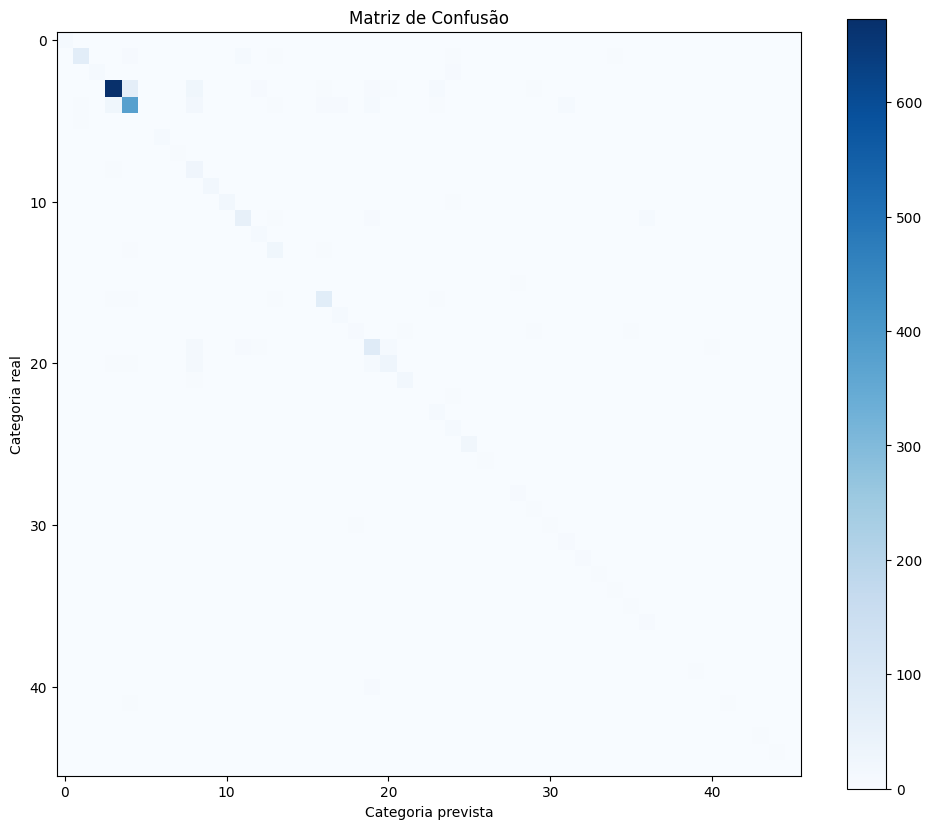

In [ ]:
from sklearn.metrics import confusion_matrix

matriz_confusao = confusion_matrix(y_teste, y_pred)

plt.figure(figsize=(12, 10))

plt.imshow(matriz_confusao, cmap="Blues")
plt.title("Matriz de Confusão")
plt.xlabel("Categoria prevista")
plt.ylabel("Categoria real")

plt.colorbar()
plt.show()

### **Análise da Matriz de Confusão**

A matriz de confusão apresenta uma concentração de valores na diagonal principal, indicando que o modelo conseguiu classificar corretamente uma parcela das notícias.

Entretanto, também são observadas classificações fora da diagonal, mostrando que algumas categorias foram confundidas pelo modelo.

O desbalanceamento do conjunto de dados também influencia a visualização, pois as categorias com maior quantidade de notícias apresentam valores mais elevados na matriz.

## **9. Inferência**

Após o treinamento e a avaliação, o modelo pode ser utilizado para classificar notícias.

A inferência será realizada de duas formas:

- utilizando uma notícia do **conjunto de teste**, que não foi utilizada durante o treinamento;
- utilizando uma **notícia externa**, simulando uma situação real de uso do sistema.

Em ambos os casos, a notícia passa pelo mesmo processo de preparação antes de ser enviada ao modelo para classificação.

### **Inferência com uma notícia do conjunto de teste**

Primeiramente, será utilizada uma notícia pertencente ao conjunto de teste.

O modelo irá determinar a categoria mais provável e o resultado será comparado com a categoria real da notícia.

In [ ]:
# Seleciona uma notícia do conjunto de teste
indice_noticia = 10

noticia_teste = x_teste_pad[indice_noticia]
categoria_real = y_teste[indice_noticia]

# Realiza a previsão
previsao = modelo.predict(
    np.expand_dims(noticia_teste, axis=0),
    verbose=0
)[0]

categoria_prevista = np.argmax(previsao)
confianca = np.max(previsao)

print(
    "Categoria real:",
    categoria_real,
    "-",
    nomes_categorias[categoria_real]
)

print(
    "Categoria prevista:",
    categoria_prevista,
    "-",
    nomes_categorias[categoria_prevista]
)

print(f"Confiança: {confianca * 100:.2f}%")

Categoria real: 5 - wheat
Categoria prevista: 1 - grain
Confiança: 42.24%


O exemplo permite comparar diretamente a categoria prevista pelo modelo com a categoria real da notícia.

Além da categoria escolhida, a confiança apresentada pelo modelo permite observar o nível de certeza associado à previsão.

In [ ]:
# Dicionário utilizado pelo dataset Reuters
word_index = datasets.reuters.get_word_index()

reverse_word_index = {
    valor + 3: palavra
    for palavra, valor in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"

# Converte a sequência novamente para texto
noticia_texto = " ".join(
    reverse_word_index.get(valor, "?")
    for valor in x_teste[indice_noticia]
)

print(noticia_texto)

<START> grain traders said they were still awaiting results of yesterday's u k intervention feed wheat tender for the home market the market sought to buy 340 000 tonnes more than double the remaining 150 000 tonnes available under the current tender however some of the tonnage included <UNK> bids for supplies in the same stores since the tenders started last july <UNK> 000 tonnes of british feed wheat have been sold back to the home market reuter 3


### **Inferência com uma Notícia Externa**

Para simular uma aplicação real do sistema, também será utilizada uma notícia externa, que não pertence ao conjunto de dados Reuters utilizado no treinamento.

Antes de ser enviada ao modelo, a notícia precisa passar pelo mesmo processo de preparação utilizado nos dados de treinamento: transformação das palavras em índices numéricos e padronização da sequência.

Após esse processamento, o modelo poderá estimar a categoria mais provável para a nova notícia.

In [ ]:
# Dicionário utilizado pelo Reuters
word_index = datasets.reuters.get_word_index()

def preparar_noticia(texto):

    # Converte para minúsculas e separa as palavras
    palavras = texto.lower().split()

    # 1 representa o marcador <START>
    sequencia = [1]

    for palavra in palavras:

        # Os índices do Reuters possuem deslocamento de +3
        indice_palavra = word_index.get(palavra)

        if indice_palavra is not None and indice_palavra + 3 < NUM_PALAVRAS:
            sequencia.append(indice_palavra + 3)
        else:
            # Palavra desconhecida
            sequencia.append(2)

    # Padroniza para o mesmo tamanho usado no treinamento
    sequencia = pad_sequences(
        [sequencia],
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    return sequencia

In [ ]:
noticia_externa = "Technology company Nova Systems reported a sharp increase in quarterly profit on Tuesday. Net income rose 28 percent to 420 million dollars, compared with 328 million dollars a year earlier. Revenue increased 14 percent, supported by strong demand for cloud computing services. The company also raised its earnings forecast for the full year."

noticia_processada = preparar_noticia(noticia_externa)

previsao_externa = modelo.predict(
    noticia_processada,
    verbose=0
)[0]

categoria_externa = np.argmax(previsao_externa)
confianca_externa = np.max(previsao_externa)

print(
    "Categoria prevista:",
    categoria_externa,
    "-",
    nomes_categorias[categoria_externa]
)

print(
    f"Confiança: {confianca_externa * 100:.2f}%"
)

Categoria prevista: 3 - earn
Confiança: 14.90%


### **Análise da Inferência Externa**

A utilização de uma notícia externa permite simular uma aplicação real do sistema, recebendo um texto que não pertence ao conjunto utilizado no treinamento.

Após o pré-processamento, o modelo identifica a categoria considerada mais provável e apresenta sua respectiva confiança.

Como uma mesma notícia pode abordar diferentes assuntos, a distribuição das probabilidades também pode refletir a dificuldade do modelo em determinar uma única categoria predominante.

## **10. Conclusão**

Neste projeto foi desenvolvido um modelo de Inteligência Artificial capaz de realizar a **classificação automática de notícias em 46 categorias**, utilizando o conjunto de dados Reuters disponibilizado pelo Keras.

Durante a exploração dos dados, foi identificado um forte **desbalanceamento entre as categorias**. Para reduzir seu impacto durante o treinamento, foram utilizados pesos de classe (*class weights*), atribuindo maior importância às categorias com menor quantidade de exemplos.

A avaliação foi realizada utilizando o conjunto de teste e diferentes métricas, incluindo **acurácia, Precision, Recall e F1-score**, permitindo analisar o desempenho do modelo considerando também o desbalanceamento existente entre as categorias.

Na etapa de inferência, o modelo foi utilizado tanto com uma notícia do conjunto de teste quanto com uma notícia externa, demonstrando o processo completo de classificação de novos textos.

O projeto apresenta, portanto, um pipeline completo de Inteligência Artificial:

**Dados → Pré-processamento → Modelo → Treinamento → Validação → Teste → Inferência**

Esse mesmo processo pode ser adaptado para aplicações de **triagem e organização automática de notícias e documentos**, auxiliando no processamento de grandes volumes de informação.

### **Possíveis melhorias**

Como trabalhos futuros, o modelo pode ser aprimorado com novas arquiteturas de redes neurais, ajustes nos parâmetros de treinamento e outras técnicas para tratamento do desbalanceamento das categorias.

Também seria possível ampliar a aplicação para outros tipos de documentos, como relatórios, mensagens e conteúdos corporativos.